# 知识图谱：TFLN 慢光色散器件 + 光子 SNN 相干前端（双项目联合）

**范围**：
- 当前项目 `tfln-dispersion-lab`：啁啾光栅脉冲压缩 → 光子蓄水池 → ISAL/HRRP 识别
  - M1 光子链路：ps 光脉冲压缩 + ns 电慢读出
  - M2 分类：digits/ModelNet40 蓄水池基准
  - M3 可调延迟与延迟预算
  - M4 距离像 + 转台 ISAL + 多波束扫描 + 自动驾驶粗分类
- 隔壁项目 `lidar-pointnet/snn`：相参脉冲串蓄水池处理链
  - M1 器件容差、M2 K 杂波检测、M3 微多普勒不变性、M4 硬件协同、M6 语义分类
  - 分类上限探测（oracle 0.74）、ANN 上限（PointNet 0.986）、3D 视角扫描

**读法**：节点按六层着色（器件/物理 → 仿真器 → 方法 → 实验 → 结论 → 应用）；边表示生成、验证、响应、互证等关系。数字均来自实测脚本/笔记本。

In [1]:
import json
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ---------------------------------------------------------------------------
# 1. 读取两个项目的实测结果，让图谱上的数字保持最新
# ---------------------------------------------------------------------------
tfln = Path("results/snn")
lidar = Path("D:/kimi_workspace/lidar-pointnet/snn")

def load_tfln():
    d = {}
    try:
        m4 = np.load(tfln / "m4_isal_results.npz", allow_pickle=True)
        d["m4_single_esn"] = float(m4["acc_profile_esn_ce"])
        d["m4_single_cnn"] = float(m4["acc_profile_cnn"])
        d["m4_16look"] = float(m4["acc_16look_cnn"])
        d["m4_small"] = float(m4["acc_small"])
    except Exception as e:
        print("m4_isal_results load failed:", e)
    try:
        bs = np.load(tfln / "m4_beam_scan_results.npz", allow_pickle=True)
        d["m4_beam_esn"] = float(bs["4beam_3step_ESN"])
        d["m4_beam_2dcnn"] = float(bs["4beam_3step_2DCNN_ceiling"])
        d["m4_beam_shuffled"] = float(bs["4beam_3step_shuffled_ESN"])
    except Exception as e:
        print("m4_beam_scan load failed:", e)
    try:
        ds = np.load(tfln / "m4_distributed_results.npz", allow_pickle=True)
        d["m4_dist_eq"] = float(ds["equatorial_2DCNN_ceiling"])
    except Exception as e:
        print("m4_distributed load failed:", e)
    try:
        af = np.load(tfln / "m4_automotive_focus_results.npz", allow_pickle=True)
        d["auto_car"] = float(af["car_vs_noncar"])
        d["auto_veh"] = float(af["vehicle_vs_nonvehicle"])
        d["auto_coarse4"] = float(af["coarse_4class"])
    except Exception as e:
        print("m4_automotive_focus load failed:", e)
    return d

def load_lidar():
    d = {}
    try:
        cls = np.load(lidar / "outputs_classify" / "classification_results.npz", allow_pickle=True)
        d["digits"] = float(cls["digits_acc"])
        d["mn_coord"] = float(cls["mn_acc_coord"])
        d["mn_echo"] = float(cls["mn_acc_echo"])
        d["mn_combined"] = float(cls["mn_acc_combined"])
        d["mn_raw"] = float(cls["mn_raw"])
    except Exception as e:
        print("classification_results load failed:", e)
    try:
        with open(lidar / "outputs" / "results.json", encoding="utf-8") as f:
            r = json.load(f)
        s_idx = -1
        d["det_iq_pd"] = r["res"]["iq"]["pd"][s_idx]
        d["det_event_pd"] = r["res"]["event"]["pd"][s_idx]
        d["det_cfar_pd"] = r["base"]["cfar_pd"][s_idx]
    except Exception as e:
        print("results.json load failed:", e)
    try:
        sem = np.load(lidar / "outputs_classify" / "m6_semantic_results.npz", allow_pickle=True)
        acc = sem.get("acc", 0.81)
        d["m6_sem"] = float(acc[0] if isinstance(acc, np.ndarray) else acc)
    except Exception as e:
        print("m6_semantic load failed:", e)
    return d

tfln_d = load_tfln()
lidar_d = load_lidar()
print("tfln:", tfln_d)
print("lidar:", lidar_d)


tfln: {'m4_single_esn': 0.38235294117647056, 'm4_single_cnn': 0.2911764705882353, 'm4_16look': 0.5088235294117647, 'm4_small': 0.35, 'm4_beam_esn': 0.6794117647058824, 'm4_beam_2dcnn': 0.8205882352941176, 'm4_beam_shuffled': 0.4970588235294118, 'm4_dist_eq': 0.8029411764705883, 'auto_car': 0.8852941176470588, 'auto_veh': 0.788235294117647, 'auto_coarse4': 0.61875}
lidar: {'digits': 0.9425, 'mn_coord': 0.3176470588235294, 'mn_echo': 0.32941176470588235, 'mn_combined': 0.4, 'mn_raw': 0.6764705882352942, 'det_iq_pd': 0.3799999952316284, 'det_event_pd': 0.07599999755620956, 'det_cfar_pd': 0.7720000147819519, 'm6_sem': 0.81}


In [2]:
# ---------------------------------------------------------------------------
# 2. 节点与边：六层知识图谱
# ---------------------------------------------------------------------------
LAYERS = ["物理/器件层", "仿真器层", "方法层", "实验层", "结论层", "应用层"]
COLORS = ["#4C72B0", "#55A868", "#C44E52", "#DD8452", "#8172B3", "#937860"]

# id, label, layer_index  (label 用空格分隔，绘图时用 textwrap 换行)
NODES = [
    # 物理/器件层
    ("dev_grat", "TFLN 啁啾光栅 / 群延迟 ~ps/nm", 0),
    ("dev_mod", "TFLN 电光调制器 / Pockels 延迟", 0),
    ("dev_sin", "SiN 平台 / 长窗低损耗", 0),
    ("dev_qd", "QD-MLL 脉冲源 / 6.74bit 权重", 0),
    ("dev_ring", "TFLN 微环 / MRR 蓄水池", 0),
    ("dev_pd", "光电探测 + ns 电读出", 0),
    # 仿真器层
    ("sim_fdtd", "Lumerical FDTD / 光栅脉压", 1),
    ("sim_hrrp", "isal_range_profile / HRRP + ISAL", 1),
    ("sim_3d", "isal_3dview / 3D 视角扫描", 1),
    ("sim_sem", "semantic_sim.py / 语义回波", 1),
    ("sim_pulse", "simulator.py / 相参脉冲串", 1),
    # 方法层
    ("m_esn", "ESN/LSM 光子蓄水池 / 256-512 神经元", 2),
    ("m_ce", "CE / Ridge 读出 + StandardScaler", 2),
    ("m_dly", "delay learning / 可调延迟训练", 2),
    ("m_cnn", "1D/2D CNN / 经验上限基准", 2),
    ("m_look", "multi-look 平均 / 散斑分集", 2),
    ("m_cfar", "CA-CFAR / FFT 经典基线", 2),
    ("m_inv", "不变特征 / 自相关 块剖面", 2),
    ("m_ann", "PointNet / PN2 / ANN 上限", 2),
    # 实验层：当前项目 tfln
    ("t_m1", "当前 M1 / ps光+ns电读出 / tau_leak内~1.0", 3),
    ("t_m2", "当前 M2 / digits 0.94 / ModelNet 0.40", 3),
    ("t_m3", "当前 M3 / 可调延迟价值 + TFLN 预算", 3),
    ("t_m4", f"当前 M4 / 单次 HRRP {tfln_d.get('m4_single_esn',0.38):.2f}", 3),
    ("t_m4_scan", f"当前 M4b / 4波束x3步 ESN {tfln_d.get('m4_beam_esn',0.68):.2f}", 3),
    ("t_m4_dist", f"当前 M4c / 分布式上限 {tfln_d.get('m4_dist_eq',0.80):.2f}", 3),
    ("t_m4_auto", f"当前 M4d / 车vs非车 {tfln_d.get('auto_car',0.89):.2f}", 3),
    # 实验层：隔壁项目 lidar
    ("l_m1", "隔壁 M1 / 器件容差", 3),
    ("l_m2", "隔壁 M2 / K杂波 CFAR 172x失效", 3),
    ("l_m3", "隔壁 M3 / 微多普勒不变性", 3),
    ("l_m4", "隔壁 M4 / 硬件协同 0.14mW", 3),
    ("l_m6", f"隔壁 M6 / 语义分类 {lidar_d.get('m6_sem',0.81):.2f}", 3),
    ("l_cl", f"隔壁上限 / oracle 0.74 / PointNet 0.986", 3),
    # 结论层
    ("c_time", "① 时标分离 / ps光 + ns电读出成立", 4),
    ("c_ceiling", f"② 蓄水池上限 / ~{tfln_d.get('m4_single_esn',0.38):.2f}-{lidar_d.get('mn_combined',0.40):.2f}", 4),
    ("c_sensing", f"③ 结构化传感增益 / {tfln_d.get('m4_single_esn',0.38):.2f}->{tfln_d.get('m4_beam_esn',0.68):.2f}", 4),
    ("c_speckle", "④ 光学粗糙目标 / 相干ISAL方位散焦", 4),
    ("c_info", f"⑤ 信息受限 / HRRP上限 {tfln_d.get('m4_beam_2dcnn',0.82):.2f}", 4),
    ("c_auto", f"⑥ 自动驾驶粗分类 / 单次剖面 {tfln_d.get('auto_car',0.89):.2f}", 4),
    ("c_hw", "⑦ 硬件-算法协同 / 蓄水池功耗 uW级", 4),
    # 应用层
    ("a_auto", "自动驾驶 LiDAR / 车 行人 骑手粗识别", 5),
    ("a_uav", "UAV 无人机 / 交通监管", 5),
    ("a_rd", "道路监控 / 尘雾 散斑环境", 5),
    ("a_sar", "SAR / 合成孔径前端", 5),
    ("a_mic", "低光子相干显微 / 散斑组织", 5),
    ("a_plan", "博士后研究计划 / M5 + plan_draft", 5),
]

EDGES = [
    ("dev_grat", "sim_fdtd", "生成"),
    ("dev_grat", "sim_hrrp", "脉压前端"),
    ("dev_mod", "m_dly", "物理载体"),
    ("dev_ring", "m_esn", "物理载体"),
    ("dev_qd", "dev_grat", "驱动光源"),
    ("dev_pd", "t_m1", "ns读出"),
    ("sim_fdtd", "t_m1", "验证"),
    ("sim_hrrp", "t_m4", "信号源"),
    ("sim_hrrp", "t_m4_scan", "信号源"),
    ("sim_hrrp", "t_m4_dist", "信号源"),
    ("sim_hrrp", "t_m4_auto", "信号源"),
    ("sim_3d", "l_cl", "信号源"),
    ("sim_sem", "l_m6", "信号源"),
    ("sim_pulse", "l_m2", "信号源"),
    ("sim_pulse", "l_m3", "信号源"),
    ("m_esn", "t_m1", ""),
    ("m_esn", "t_m2", ""),
    ("m_esn", "t_m4", ""),
    ("m_esn", "t_m4_scan", ""),
    ("m_esn", "t_m4_dist", ""),
    ("m_esn", "t_m4_auto", ""),
    ("m_esn", "l_m2", ""),
    ("m_esn", "l_m3", ""),
    ("m_esn", "l_m6", ""),
    ("m_ce", "t_m4", "读出"),
    ("m_dly", "t_m3", ""),
    ("m_cnn", "t_m4", "上限基准"),
    ("m_cnn", "t_m4_scan", "上限基准"),
    ("m_look", "t_m4", "散斑分集"),
    ("m_cfar", "l_m2", "对照"),
    ("m_inv", "l_m3", "决定性"),
    ("m_ann", "l_cl", "上限"),
    ("t_m1", "c_time", ""),
    ("t_m2", "c_ceiling", ""),
    ("l_m6", "c_ceiling", "互证"),
    ("t_m4", "c_ceiling", ""),
    ("t_m4_scan", "c_sensing", ""),
    ("t_m4_dist", "c_sensing", ""),
    ("t_m4", "c_speckle", ""),
    ("t_m4_scan", "c_speckle", "响应"),
    ("t_m4_scan", "c_info", ""),
    ("t_m4_dist", "c_info", ""),
    ("t_m4_auto", "c_auto", ""),
    ("l_m4", "c_hw", ""),
    ("l_cl", "c_info", "定界"),
    ("c_auto", "a_auto", ""),
    ("c_sensing", "a_auto", ""),
    ("c_speckle", "a_sar", ""),
    ("c_info", "a_plan", ""),
    ("c_hw", "a_plan", ""),
    ("c_ceiling", "a_plan", ""),
    ("c_time", "a_plan", ""),
    ("l_m2", "a_rd", "散斑/尘雾"),
    ("l_m3", "a_uav", ""),
    ("l_m6", "a_rd", ""),
]

kg = {
    "nodes": [{"id": n, "label": l, "layer": LAYERS[c]} for n, l, c in NODES],
    "edges": [{"src": s, "dst": d, "relation": r} for s, d, r in EDGES],
}
with open("kg_data.json", "w", encoding="utf-8") as f:
    json.dump(kg, f, ensure_ascii=False, indent=2)
print("saved kg_data.json: nodes=%d edges=%d" % (len(NODES), len(EDGES)))


saved kg_data.json: nodes=45 edges=55


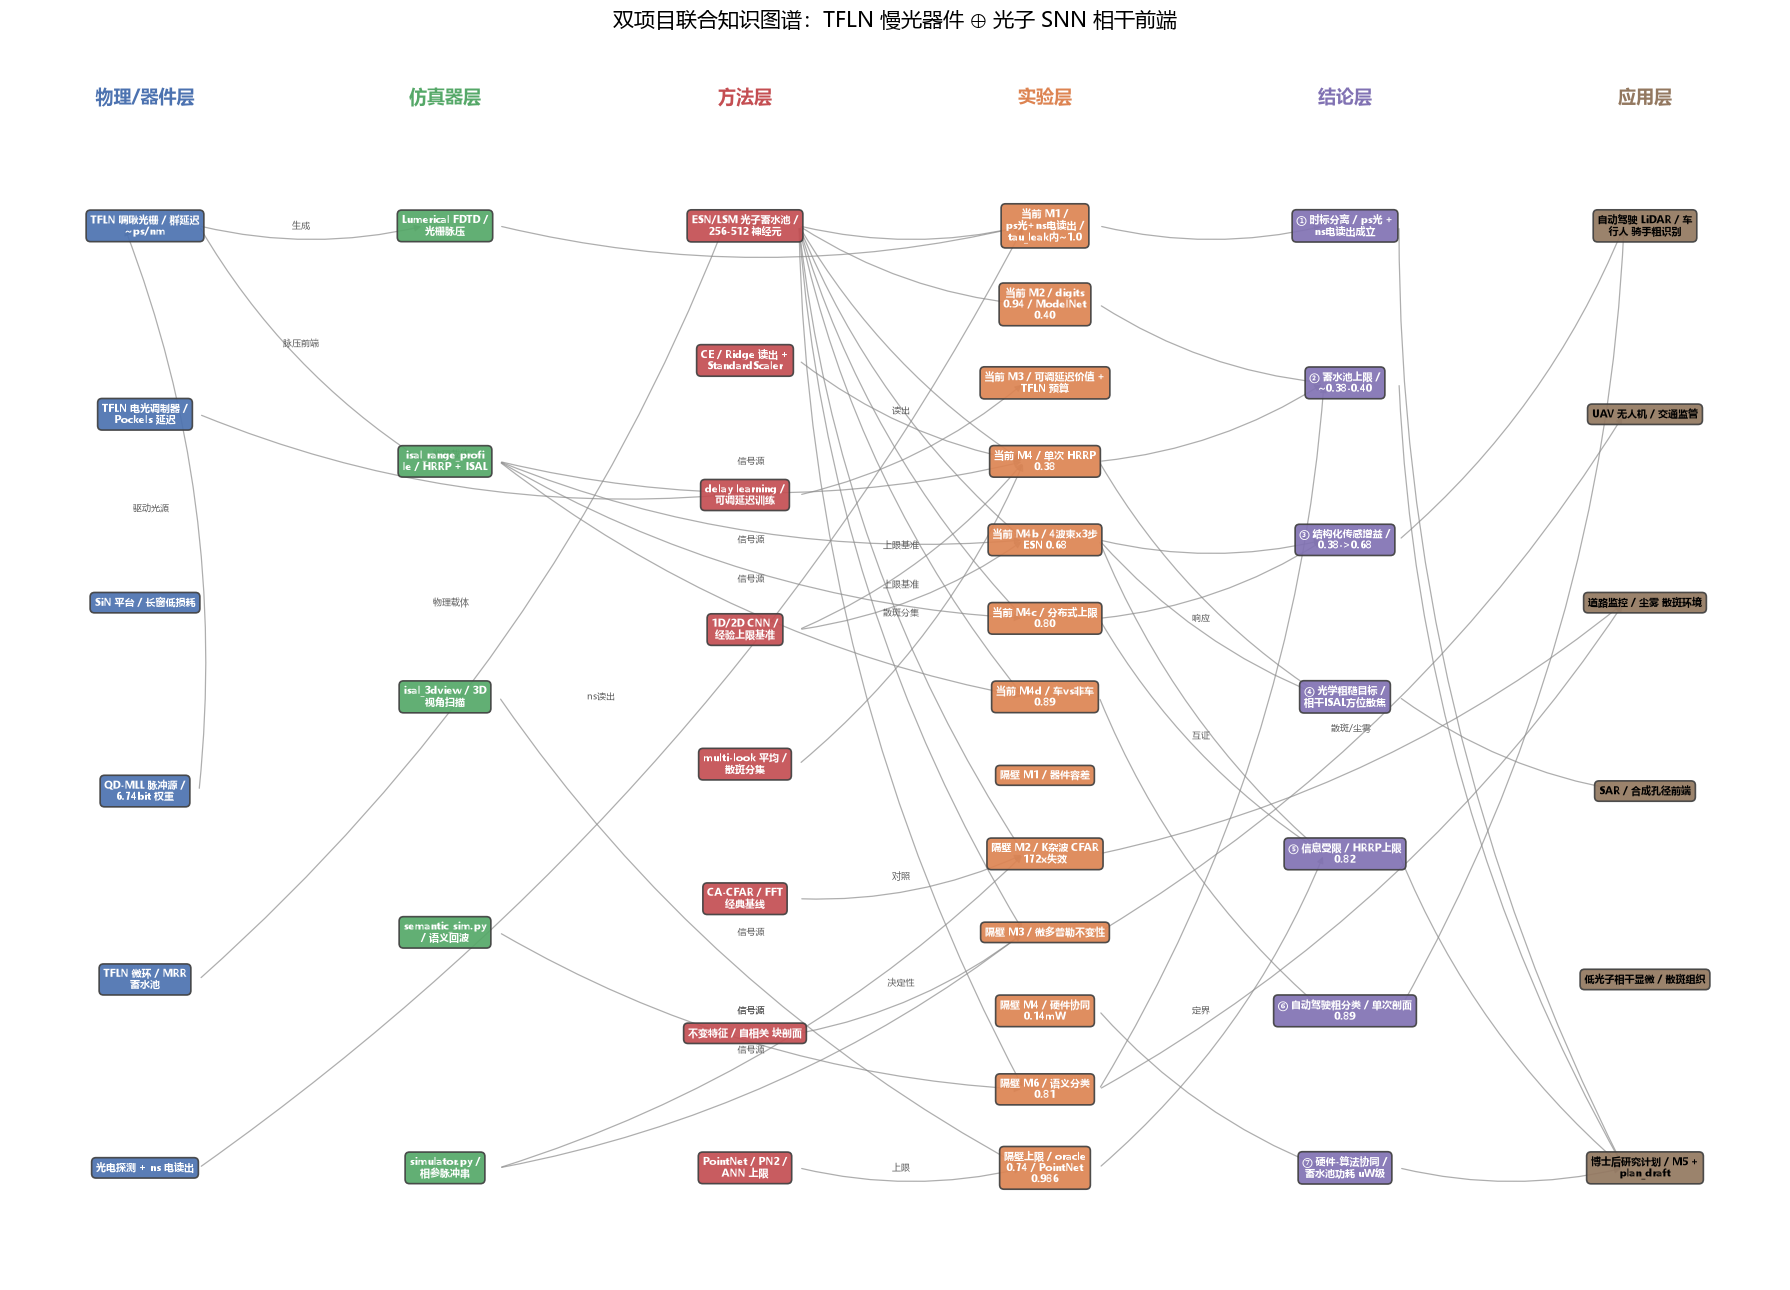

nodes=45 edges=55


In [3]:
# ---------------------------------------------------------------------------
# 3. 绘制六层知识图谱
# ---------------------------------------------------------------------------
G = nx.DiGraph()
for nid, lab, col in NODES:
    G.add_node(nid, label=lab, layer=col)
for s, d, r in EDGES:
    G.add_edge(s, d, relation=r)

pos = {}
by_layer = {i: [] for i in range(len(LAYERS))}
for nid, lab, col in NODES:
    by_layer[col].append(nid)
for col, nids in by_layer.items():
    ys = np.linspace(0.92, 0.08, len(nids))
    for nid, y in zip(nids, ys):
        pos[nid] = (col, y)

fig, ax = plt.subplots(figsize=(18, 13))
for s, d, data in G.edges(data=True):
    x0, y0 = pos[s]
    x1, y1 = pos[d]
    ax.annotate("", xy=(x1 - 0.07, y1), xytext=(x0 + 0.18, y0),
                arrowprops=dict(arrowstyle="-|>", color="0.55", lw=0.9,
                                alpha=0.7, connectionstyle="arc3,rad=0.12"))
    rel = data.get("relation", "")
    if rel:
        xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
        ax.text(xm + 0.02, ym, rel, fontsize=6.5, color="0.35", style="italic",
                ha="center", va="center")
for nid, lab, col in NODES:
    x, y = pos[nid]
    ax.text(x, y, textwrap.fill(lab, 16), fontsize=7.5, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.42", fc=COLORS[col], ec="0.25",
                      alpha=0.92, lw=1.2),
            color="w" if col != 5 else "k", weight="bold")
for i, (name, c) in enumerate(zip(LAYERS, COLORS)):
    ax.text(i, 1.03, name, fontsize=13, ha="center", fontweight="bold", color=c)

ax.set_xlim(-0.45, len(LAYERS) - 0.55)
ax.set_ylim(-0.02, 1.08)
ax.axis("off")
ax.set_title("双项目联合知识图谱：TFLN 慢光器件 ⊕ 光子 SNN 相干前端",
             fontsize=15, pad=14)
plt.tight_layout()
plt.show()
print("nodes=%d edges=%d" % (G.number_of_nodes(), G.number_of_edges()))

## 图 2 · 证据链子图：从“蓄水池上限”到两条破局路径

两条项目共同压出的核心结论是：**固定随机蓄水池在复杂 3D 任务上饱和在 ~0.35–0.42**。这不是方法失败，而是“单次 1D 投影”的信息前沿。由此分出两条互补破局路径：

- **路径 A（器件/算法）**：用 TFLN 电光可调延迟替换固定抽头，做硬件感知的 delay learning——当前项目 M3 定量回答延迟预算与训练价值；
- **路径 B（传感几何）**：用已知角度的有序多波束/扫描把几何信息写进时序——当前项目 M4 中 0.38→0.68，打乱顺序跌回 0.50 证明顺序本身就是信息；这也是对隔壁 M4“相干 ISAL 被散斑方位散焦”的直接回应：放弃方位相干，走幅度域多角度。

汇聚点：**信息受限 + 硬件-传感-算法协同**——蓄水池的价值在信息前沿，不在无限表达力。

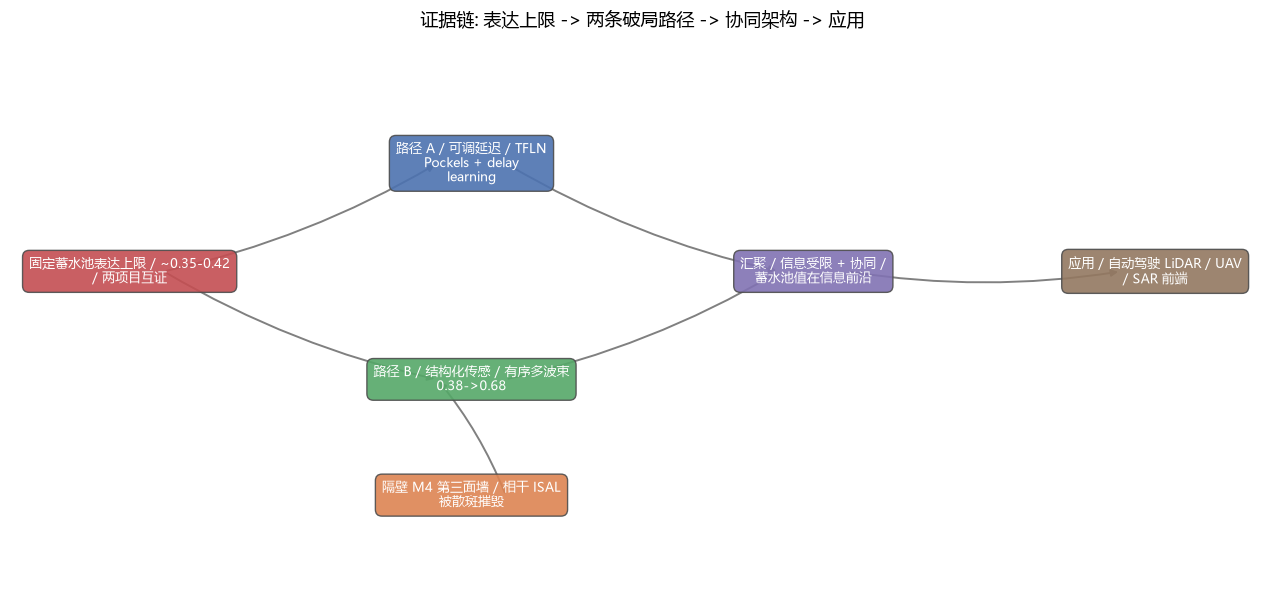

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
story = [
    ("固定蓄水池表达上限 / ~0.35-0.42 / 两项目互证", 0, 0.5, "#C44E52"),
    ("路径 A / 可调延迟 / TFLN Pockels + delay learning", 1, 0.78, "#4C72B0"),
    ("路径 B / 结构化传感 / 有序多波束 0.38->0.68", 1, 0.22, "#55A868"),
    ("隔壁 M4 第三面墙 / 相干 ISAL 被散斑摧毁", 1, -0.08, "#DD8452"),
    ("汇聚 / 信息受限 + 协同 / 蓄水池值在信息前沿", 2, 0.5, "#8172B3"),
    ("应用 / 自动驾驶 LiDAR / UAV / SAR 前端", 3, 0.5, "#937860"),
]
links = [(0, 1), (0, 2), (3, 2), (1, 4), (2, 4), (4, 5)]
for a, b in links:
    x0, y0 = story[a][1], story[a][2]
    x1, y1 = story[b][1], story[b][2]
    ax.annotate("", xy=(x1 - 0.10, y1), xytext=(x0 + 0.10, y0),
                arrowprops=dict(arrowstyle="-|>", color="0.5", lw=1.4,
                                connectionstyle="arc3,rad=0.08"))
for lab, x, y, c in story:
    ax.text(x, y, textwrap.fill(lab, 22), fontsize=9.5, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.5", fc=c, ec="0.3", alpha=0.9),
            color="w")
ax.set_xlim(-0.35, 3.35)
ax.set_ylim(-0.3, 1.1)
ax.axis("off")
ax.set_title("证据链: 表达上限 -> 两条破局路径 -> 协同架构 -> 应用", fontsize=13, pad=10)
plt.tight_layout()
plt.show()

## 双项目里程碑对照表（数字均来自实测）

### 当前项目 `tfln-dispersion-lab`

| 里程碑 | 核心数字/结论 | 出处 |
|---|---|---|
| M1 光子链路 | ps 光脉压 + ns 电慢读出：τ_leak 内读出准确率 ~1.0；时标分离成立 | `milestone-M1-photonic-chain.ipynb` |
| M2 SNN 分类 | digits 0.94；ModelNet40 单次投影 ESN 0.38；与隔壁 demo 互证上限 | `milestone-M2-snn-classification.ipynb` |
| M3 可调延迟 | delay learning 价值边界 + TFLN ns 级延迟/损耗预算 | `milestone-M3-delay-learning-and-budget.ipynb` |
| M4 ISAL/HRRP | 单次随机 HRRP 0.38；4 波束×3 步扫描 ESN 0.68（2D CNN 上限 0.82）；赤道面分布式上限 0.80；相干 ISAL θ_c<0.3° 散焦 | `milestone-M4-isal-range-profile.ipynb` |
| M4d 自动驾驶粗分类 | **car vs non-car 0.885；vehicle vs non-vehicle 0.788；coarse 4-class 0.619** | `isal_automotive_focus.py` |
| 器件 | chirp2d 啁啾光栅群延迟纹波 RMS ~1 ps | `lumerical/results/chirp2d.npz` |

### 隔壁项目 `lidar-pointnet/snn`

| 里程碑 | 核心数字 | 出处 |
|---|---|---|
| M1 器件容差 | 纹波 ~1 ps / leak 失配 / 6 bit 量化：性能基本无损 | `notebooks/m1_device_spec.ipynb` |
| M2 非高斯杂波 | CFAR 虚警膨胀 172× 全失效；LSM 仍保持检测 | `notebooks/m2_non_gaussian_clutter.ipynb` |
| M3 微多普勒 | 不变性决定分类：自相关+线性 0.71；池状态+二次核 0.25 | `notebooks/m3_microdoppler_classification.ipynb` |
| M4 硬件协同 | 4.3×10⁴ ops/CPI、1.36 nJ/CPI、0.14 mW@100 kHz | `notebooks/m4_hardware_codesign.ipynb` |
| M6 语义分类 | 块+补偿链 0.79–0.81；v1 单门 0.26 | `notebooks/m6_semantic_classification.ipynb` |
| 上限探测 | oracle 去载波 0.74；PointNet 0.986 | `cls_ceiling_results.npz`, `ann_bench` |

### 交叉咬合关系

1. **啁啾光栅**（当前项目生成）→ 隔壁 M1 做纹波容差验证 + 当前 M4 做 ISAL 脉压前端；
2. **蓄水池上限 ~0.4**（当前 M2 与隔壁 demo 独立互证）→ 共同提出两条破局路径；
3. **相干 ISAL 散焦**（当前 M4）→ 多波束幅度域扫描（当前 M4b）是直接回应；
4. **delay learning**（当前 M3）+ 隔壁检测/扫描结论 → 共同进入博士后计划 WP；
5. **自动驾驶粗分类 0.885**（当前 M4d）→ 把“单发压缩 → spike → 蓄水池”的低延迟链路落地到车/行人/骑手识别应用。

In [5]:
print("知识图谱构建完成。文件：kg_data.json, knowledge_graph.ipynb")

知识图谱构建完成。文件：kg_data.json, knowledge_graph.ipynb
